# Bates Simulator — Visual Verification
Loads the simulated Bates paths (Heston SV + compound Poisson jumps) and checks correctness visually.

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

In [2]:
DATA_DIR = Path('..') / 'data'

S, V, VarPrice = torch.load(DATA_DIR / 'bates_paths.pt', weights_only=True)  # each (M, N+1)
meta = json.loads((DATA_DIR / 'bates_paths.json').read_text())

S0      = meta['S0']
v0      = meta['v0']
kappa   = meta['kappa']
theta   = meta['theta']
xi      = meta['xi']
rho     = meta['rho']
mu_J    = meta['mu_J']
sigma_J = meta['sigma_J']
lam     = meta['lam']
T       = meta['T']
N       = meta['N']
M       = meta['M']

print(f'Loaded {M:,} paths × {N+1} time-points')
print(f'S0={S0}, v0={v0}, kappa={kappa}, theta={theta}, xi={xi}, rho={rho}')
print(f'mu_J={mu_J}, sigma_J={sigma_J}, lam={lam}, T={T:.4f}')

Loaded 50,000 paths × 31 time-points
S0=100.0, v0=0.0574, kappa=0.4963, theta=0.065, xi=0.2286, rho=-0.99
mu_J=0.1791, sigma_J=0.1346, lam=0.1382, T=0.0822


## 1 · Sample stock price paths (n=20)

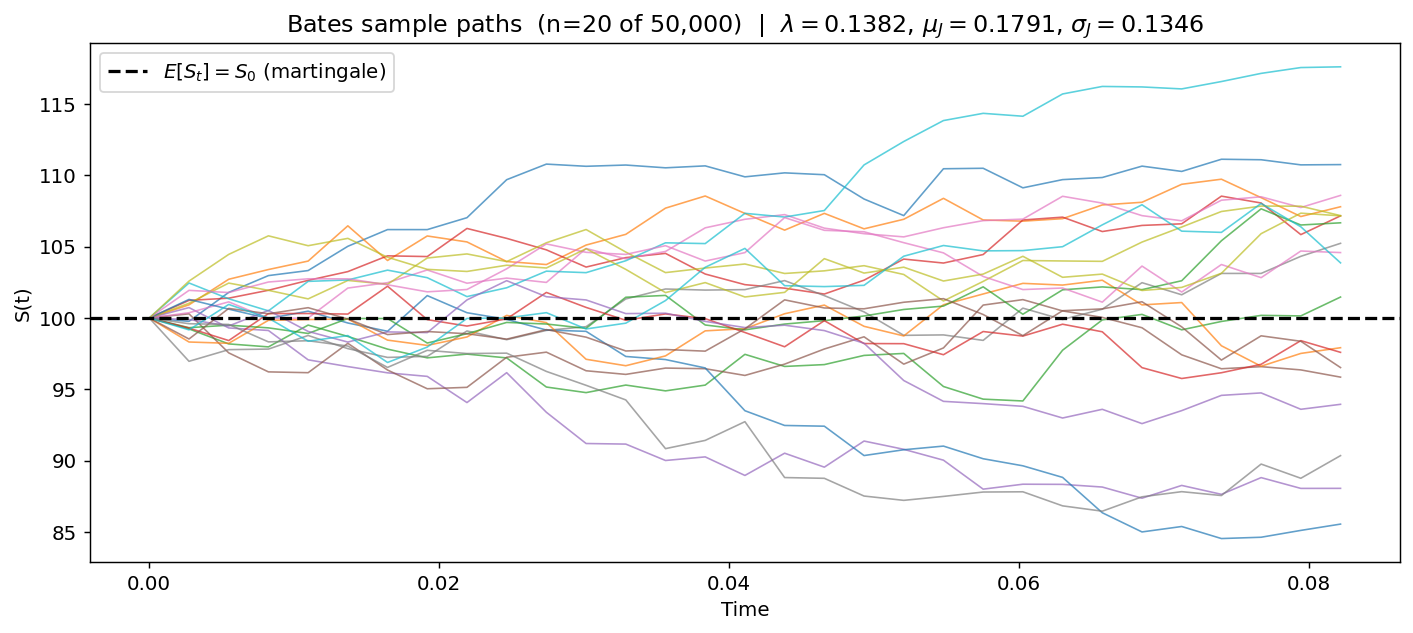

In [3]:
N_SAMPLE = 20
t = torch.linspace(0, T, N + 1).numpy()

torch.manual_seed(0)
idx = torch.randperm(M)[:N_SAMPLE]
S_sample = S[idx].numpy()  # (20, N+1)

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(N_SAMPLE):
    ax.plot(t, S_sample[i], lw=0.9, alpha=0.7)

# Bates with jump compensator is a martingale under risk-neutral measure → E[S_t] = S0
ax.axhline(S0, color='black', lw=1.8, ls='--', label=r'$E[S_t] = S_0$ (martingale)')

ax.set_xlabel('Time')
ax.set_ylabel('S(t)')
ax.set_title(
    f'Bates sample paths  (n={N_SAMPLE} of {M:,})  |  '
    rf'$\lambda={lam}$, $\mu_J={mu_J}$, $\sigma_J={sigma_J}$'
)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.show()

## 2 · Sample variance paths (n=20)

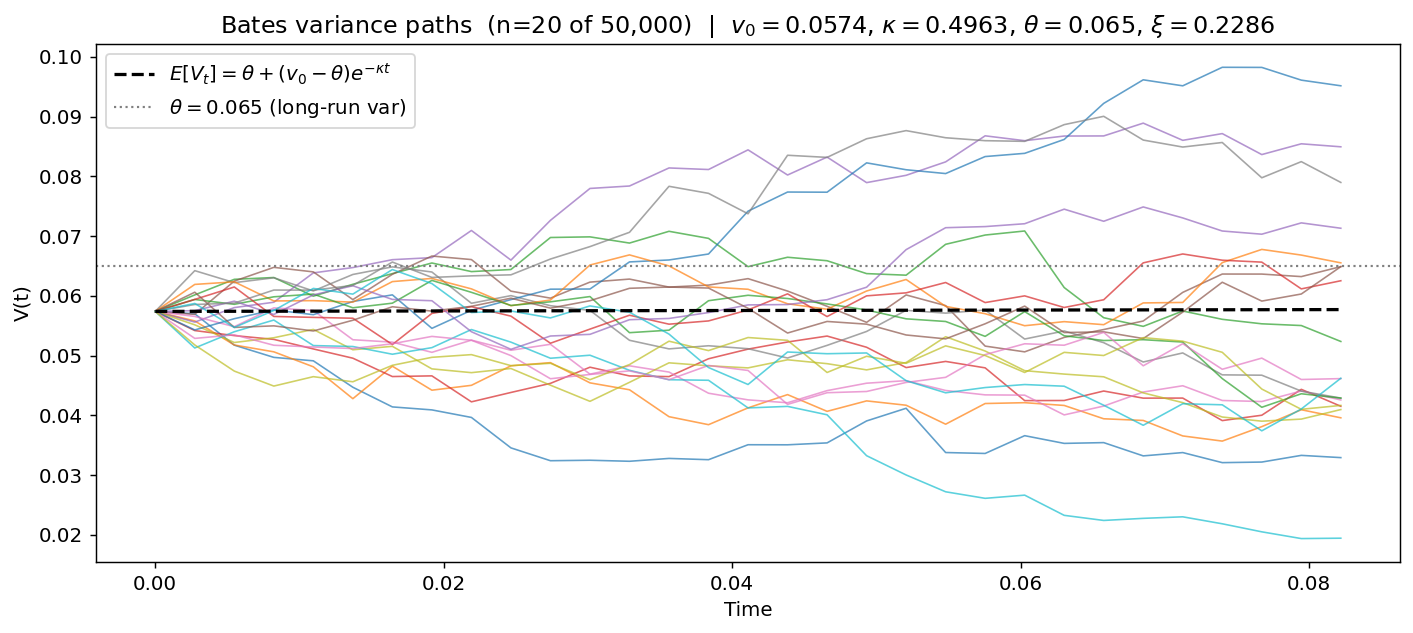

In [4]:
V_sample = V[idx].numpy()  # same 20 paths

# Theoretical mean of CIR variance: E[V_t] = theta + (v0 - theta)*exp(-kappa*t)
mean_V_theory = theta + (v0 - theta) * np.exp(-kappa * t)

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(N_SAMPLE):
    ax.plot(t, V_sample[i], lw=0.9, alpha=0.7)

ax.plot(t, mean_V_theory, 'k--', lw=1.8,
        label=r'$E[V_t] = \theta + (v_0-\theta)e^{-\kappa t}$')
ax.axhline(theta, color='gray', lw=1.2, ls=':', label=rf'$\theta={theta}$ (long-run var)')

ax.set_xlabel('Time')
ax.set_ylabel('V(t)')
ax.set_title(
    f'Bates variance paths  (n={N_SAMPLE} of {M:,})  |  '
    rf'$v_0={v0}$, $\kappa={kappa}$, $\theta={theta}$, $\xi={xi}$'
)
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Terminal distribution $S_T$

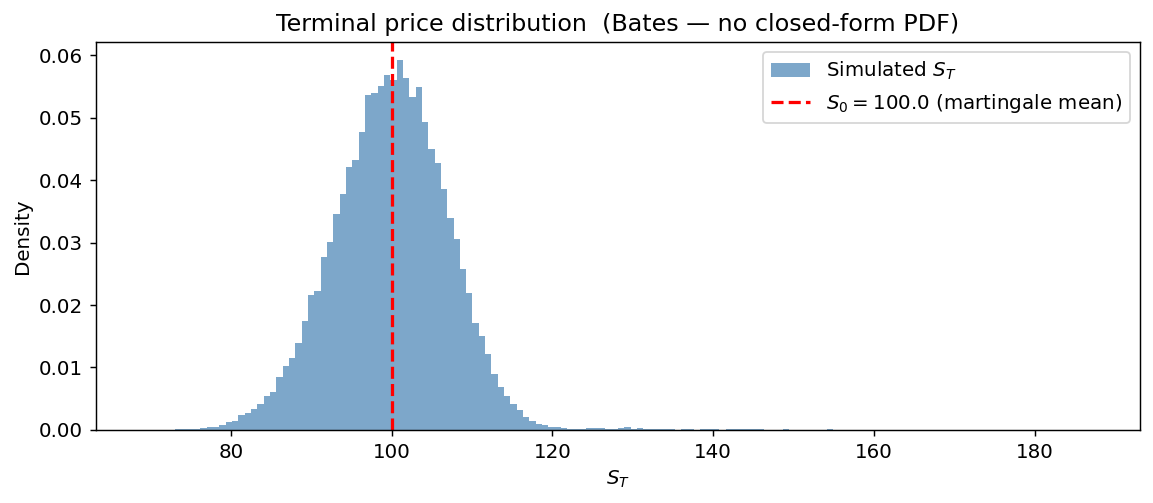

In [5]:
S_T = S[:, -1].numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(S_T, bins=150, density=True, color='steelblue', alpha=0.7, label='Simulated $S_T$')
ax.axvline(S0, color='red', lw=1.8, ls='--', label=f'$S_0 = {S0}$ (martingale mean)')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Density')
ax.set_title('Terminal price distribution  (Bates — no closed-form PDF)')
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Moment checks

In [6]:
V_T = V[:, -1].numpy()

E_S_sim  = S_T.mean()
E_S_th   = S0  # martingale

E_V_sim  = V_T.mean()
E_V_th   = theta + (v0 - theta) * np.exp(-kappa * T)

print(f'              Simulated       Theory')
print(f'E[S_T]     {E_S_sim:>12.4f}   {E_S_th:>10.4f}')
print(f'E[V_T]     {E_V_sim:>12.6f}   {E_V_th:>10.6f}')
print(f'Rel error (E[S_T]) : {abs(E_S_sim - E_S_th)/E_S_th:.4%}')
print(f'Rel error (E[V_T]) : {abs(E_V_sim - E_V_th)/E_V_th:.4%}')

              Simulated       Theory
E[S_T]         100.0261     100.0000
E[V_T]         0.057631     0.057704
Rel error (E[S_T]) : 0.0261%
Rel error (E[V_T]) : 0.1254%


---
## 5 · Custom simulation — tweak hyperparameters here

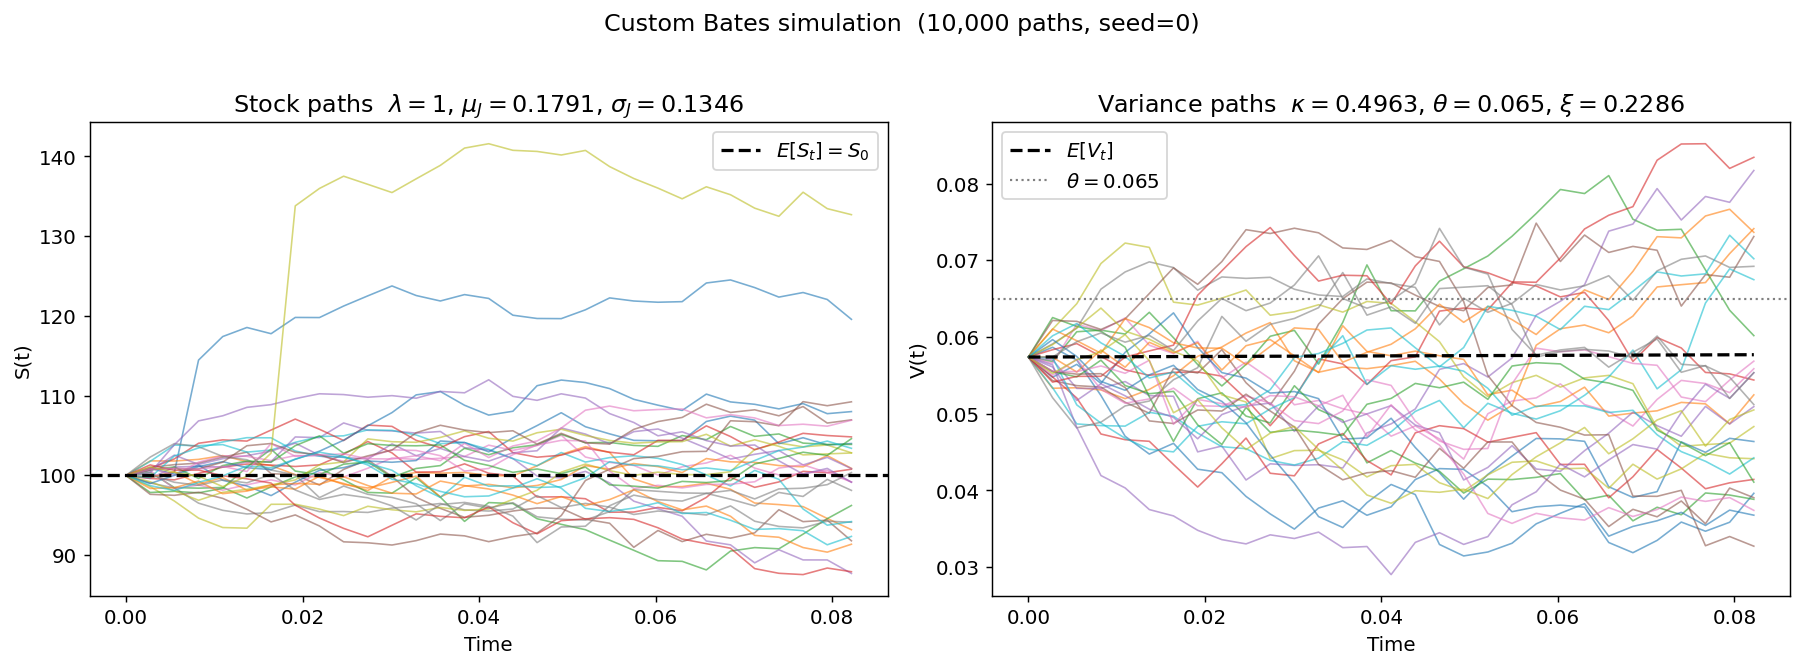

In [7]:
from src.bates_simulator import BatesParams, BatesSimulator

# ── edit anything below ────────────────────────────────────────────────────
custom_params = BatesParams(
    S0      = 100.0,
    v0      = 0.0574,
    kappa   = 0.4963,
    theta   = 0.0650,
    xi      = 0.2286,
    rho     = -0.990,
    mu_J    = 0.1791,
    sigma_J = 0.1346,
    lam     = 1,
    T       = 30 / 365,
    N       = 30,
    M       = 10_000,   # smaller M is fast enough for exploration
)
SEED   = 0
N_SHOW = 30             # number of sample paths to plot
# ───────────────────────────────────────────────────────────────────────────

S_c, V_c, _ = BatesSimulator(custom_params).simulate(seed=SEED)

p   = custom_params
t_c = np.linspace(0, p.T, p.N + 1)
mean_V_c = p.theta + (p.v0 - p.theta) * np.exp(-p.kappa * t_c)

torch.manual_seed(SEED)
idx_c  = torch.randperm(p.M)[:N_SHOW]
S_show = S_c[idx_c].numpy()
V_show = V_c[idx_c].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i in range(N_SHOW):
    ax.plot(t_c, S_show[i], lw=0.9, alpha=0.6)
ax.axhline(p.S0, color='black', lw=1.8, ls='--', label=r'$E[S_t]=S_0$')
ax.set_xlabel('Time'); ax.set_ylabel('S(t)')
ax.set_title(rf'Stock paths  $\lambda={p.lam}$, $\mu_J={p.mu_J}$, $\sigma_J={p.sigma_J}$')
ax.legend(); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

ax = axes[1]
for i in range(N_SHOW):
    ax.plot(t_c, V_show[i], lw=0.9, alpha=0.6)
ax.plot(t_c, mean_V_c, 'k--', lw=1.8, label=r'$E[V_t]$')
ax.axhline(p.theta, color='gray', lw=1.2, ls=':', label=rf'$\theta={p.theta}$')
ax.set_xlabel('Time'); ax.set_ylabel('V(t)')
ax.set_title(rf'Variance paths  $\kappa={p.kappa}$, $\theta={p.theta}$, $\xi={p.xi}$')
ax.legend()

plt.suptitle(f'Custom Bates simulation  ({p.M:,} paths, seed={SEED})', y=1.02)
plt.tight_layout()
plt.show()